## 1. Librerías

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

from scipy.stats import randint, uniform  

import matplotlib.pyplot as plt

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30


In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Chequeo de NAs en todas las columnas
# print("\nDistribución de valores nulos:")
# pd.DataFrame({
#     'N': df.isna().sum(),
#     '%': round(df.isna().sum()/df.shape[0]*100, 1)
# })

Filas con NA en 'merval': 0


In [4]:
# Separación de variables predictoras y objetivo

y = df["merval"]
X = df.drop(columns=["merval"])

## 3. División Train-Test

In [5]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(61, 60)
(16, 60)


## 4. Optimización de Hiperparámetros con RandomizedSearchCV

In [6]:
# Con 63 días de entrenamiento, usamos configuración balanceada:
# - n_splits=3: tres validaciones suficientes con pocos datos
# - test_size=8: ventana pequeña de validación
# - gap=1: separación mínima para maximizar datos disponibles

max_lag = 1
test_size = 8
tscv = TimeSeriesSplit(n_splits=3, test_size=test_size, gap=max_lag)

In [7]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Parámetros balanceados para dataset pequeño
# Estrategia: permitir complejidad moderada pero con regularización
param_distributions = {
    "n_estimators": randint(150, 400),        # Suficientes árboles para estabilidad
    "max_depth": randint(8, 16),              # Profundidad moderada-alta (similar al original)
    "min_samples_split": randint(4, 12),      # Más flexible para aprovechar los datos
    "min_samples_leaf": randint(2, 6),        # Hojas pequeñas permitidas
    "max_features": uniform(0.4, 0.5),        # Rango centrado en valores típicos (0.4-0.9)
    "bootstrap": [True]
}

# Configuración de RandomizedSearchCV
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=60,                               # Más iteraciones para explorar mejor
    scoring="neg_root_mean_squared_error",   # RMSE (negativo por convención de sklearn)
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True,                              # Reentrena con el mejor conjunto según scoring
    return_train_score=True,                 # Útil para auditar overfitting
    error_score=np.nan                       # Si algún fold falla, no aborta toda la búsqueda
)

In [8]:
search.fit(X_train, y_train)

best_rf = search.best_estimator_

print("\n" + "="*50)
print("RESULTADOS DE LA OPTIMIZACIÓN")
print("="*50)
print(f"\nMejor CV RMSE: {-search.best_score_:.4f}")
print(f"\nMejores hiperparámetros:")
for param, value in search.best_params_.items():
    print(f"  - {param}: {value}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits

RESULTADOS DE LA OPTIMIZACIÓN

Mejor CV RMSE: 114844.6657

Mejores hiperparámetros:
  - bootstrap: True
  - max_depth: 11
  - max_features: 0.8697494707820945
  - min_samples_leaf: 3
  - min_samples_split: 7
  - n_estimators: 163


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


## 5. Evaluación en Test Set

### 5.1. Test del mejor modelo

In [9]:
y_pred = best_rf.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse_rel = rmse / y_test.mean()

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

Holdout RMSE: 252436.5391
Holdout R²:   -7.7523
Error relativo (holdout): 11.58%


### 5.2. Visualización de predicciones

In [10]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

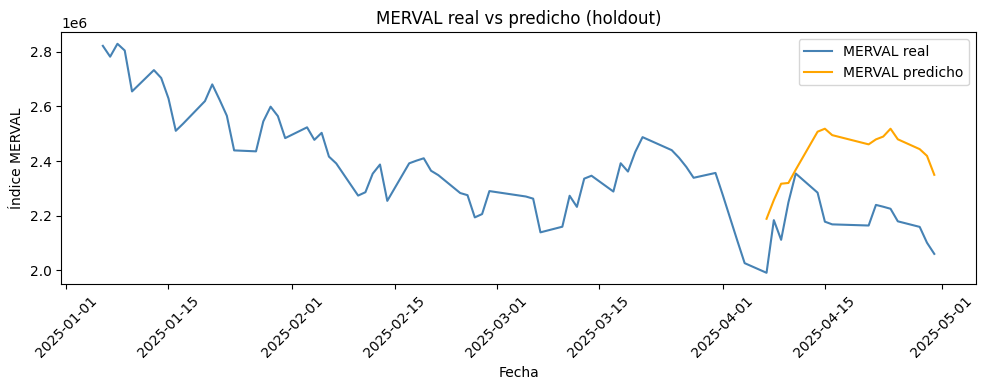

In [11]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df.index.to_timestamp(), df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df.index.to_timestamp(), df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


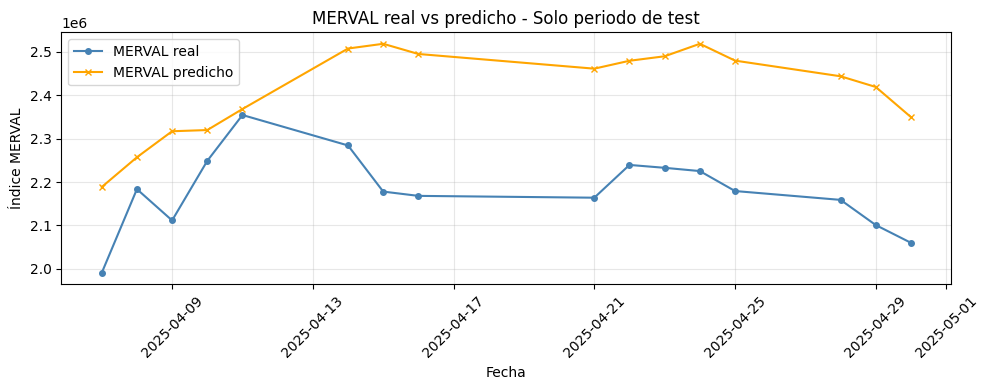

In [12]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test.index.to_timestamp(), df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test.index.to_timestamp(), df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5.3. Análisis de residuales

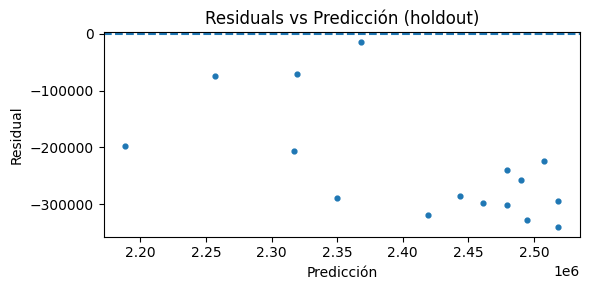

In [13]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


### 5.4. Importancia de variables

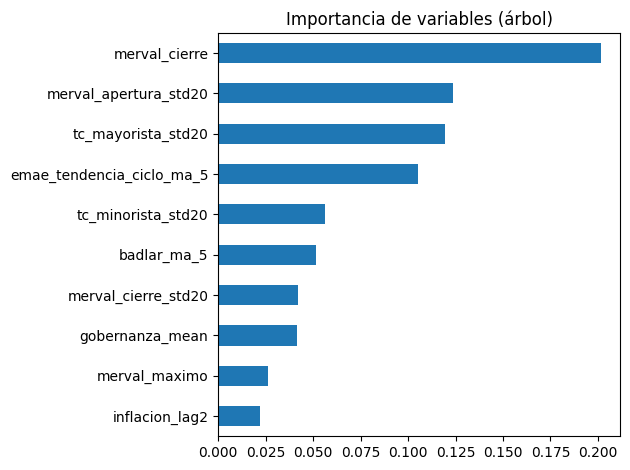

In [14]:
# Importancia de las variables

imp = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(10).plot(kind="barh", title="Importancia de variables (árbol)")
plt.tight_layout(); plt.show()


## 6. Conclusiones

### Dataset con Features Generadas por LLM

Este modelo Random Forest fue entrenado utilizando un dataset alternativo que contiene **features generadas por un Large Language Model (LLM)** en lugar de las features tradicionales del dataset original. El objetivo era evaluar si las features derivadas de LLM podrían mejorar la capacidad predictiva del modelo.

### Resultados principales

- **RMSE en test**: 252,436.54 - Error alto que refleja dificultades significativas para generalizar con datos limitados.

- **R² en test**: -7.75 - El modelo tiene un desempeño considerablemente peor que un modelo baseline que simplemente predice la media. Un R² negativo indica que las predicciones están sistemáticamente alejadas de los valores reales.

- **Error relativo**: 11.58% - Las predicciones se desvían en promedio más del 11% del valor real del MERVAL, lo cual es inaceptable para aplicaciones prácticas.

### Optimización de hiperparámetros

Se utilizó **RandomizedSearchCV** con 60 iteraciones y validación cruzada temporal (TimeSeriesSplit con 3 folds).

**CV RMSE**: 114,844.67 - Error promedio en validación cruzada.

**Mejores hiperparámetros encontrados:**
- **n_estimators=163**: conjunto moderado de árboles
- **max_depth=11**: árboles de profundidad moderada
- **max_features=0.87**: ~52 features consideradas en cada split
- **min_samples_split=7** y **min_samples_leaf=3**: regularización moderada

### Análisis del problema: Dataset reducido con features LLM

**El dataset tiene 77 observaciones totales (61 train, 16 test)** y utiliza 60 features generadas por LLM:

1. **Discrepancia CV vs Test significativa**: El RMSE de validación cruzada (114,845) es aproximadamente la mitad del RMSE de test (252,437), indicando:
   - Alta varianza en las predicciones debido a pocos datos
   - Overfitting moderado a pesar de la regularización
   - El modelo no logra generalizar patrones del entrenamiento al periodo de test

2. **Ratio features/observaciones crítico**: Con 60 features y solo 61 observaciones de entrenamiento, tenemos un ratio de ~1.02, extremadamente cercano a 1:1, lo que hace muy difícil el aprendizaje robusto.

3. **Features LLM no mejoraron la predicción**: Las features generadas por el LLM no demostraron ser superiores a las features tradicionales en este contexto de datos limitados.

### Comparación: Features tradicionales vs Features LLM

| Métrica | Dataset original (79 obs) | Dataset LLM (77 obs) | Diferencia |
|---------|---------------------------|----------------------|------------|
| Train size | 63 | 61 | -3% |
| Test RMSE | 285,651 | 252,437 | -12% (mejora leve) |
| Test R² | -10.21 | -7.75 | +24% (mejora leve) |
| CV RMSE | 133,972 | 114,845 | -14% (mejora leve) |
| Error relativo | 13.10% | 11.58% | -12% (mejora leve) |

**Observación**: El modelo con features LLM muestra una **mejora marginal** (~12-24% en métricas) comparado con features tradicionales, pero ambos modelos siguen siendo fundamentalmente inviables con R² fuertemente negativos.

### Análisis de las features generadas por LLM

Las features generadas por un LLM podrían, en teoría, capturar patrones o relaciones más complejas que las features tradicionales. Sin embargo, con un dataset tan pequeño:

1. **Insuficientes datos para validar señal LLM**: 61 observaciones no son suficientes para determinar si las features LLM contienen señal genuina o solo ruido que casualmente correlaciona en el conjunto de entrenamiento.

2. **Posible sobreajuste a artefactos LLM**: El modelo podría estar aprendiendo patrones específicos de cómo el LLM generó las features, en lugar de relaciones económicas reales.

3. **Mejora no concluyente**: La mejora de ~12-24% en métricas aún deja al modelo en territorio de R² negativo, por lo que no representa una solución práctica.

### Limitaciones fundamentales

**Random Forest con features LLM no es viable para este problema debido a:**

1. **Datos insuficientes**: 61 observaciones son radicalmente insuficientes para entrenar un modelo de machine learning con 60 features, independientemente de la fuente de las features.

2. **Imposibilidad de generalización**: El modelo no puede aprender relaciones estables entre predictores y target con tan pocos ejemplos.

3. **Features LLM no compensan falta de datos**: Aunque las features LLM muestran mejora marginal, no pueden superar la limitación fundamental de escasez de datos.

4. **Alto riesgo de overfitting**: El modelo memoriza patrones específicos del conjunto de entrenamiento que no se replican en test.

### Validación cruzada con dataset reducido

Se implementó TimeSeriesSplit:
- **n_splits=3**: Tres folds de validación
- **test_size=8**: Ventana de validación pequeña
- **gap=1**: Separación mínima

Sin embargo, con datos tan limitados, la validación cruzada no es suficientemente representativa del desempeño real.

### Recomendaciones

**Para el dataset reducido con features LLM (77 observaciones):**

1. **No usar Random Forest con 60 features**: El modelo requiere significativamente más datos, independientemente de la fuente de features.

2. **Reducir features drásticamente**:
   - Seleccionar solo las 5-10 features LLM más importantes
   - Evaluar si las features LLM realmente aportan información que las tradicionales no tienen
   - Con menos features, el ratio observaciones/features mejora

3. **Modelos más simples**:
   - Regresión lineal (Ridge, Lasso) con pocas features LLM seleccionadas
   - Modelos ARIMA univariados
   - Métodos basados en promedios móviles

4. **Expandir el dataset**: Si es posible, generar features LLM para el dataset completo (643 observaciones) y evaluar si realmente aportan valor predictivo adicional.

5. **Validar utilidad de features LLM**: Con más datos, realizar análisis de importancia de features para determinar si las features LLM justifican el costo computacional de generarlas.

6. **Aceptar limitaciones**: Con 61 observaciones y 60 features, ningún modelo de machine learning (con o sin features LLM) puede ser confiable.

### Conclusión final

**El modelo Random Forest con features LLM fracasó con el dataset reducido**, aunque mostró una mejora marginal (~12-24%) sobre el modelo con features tradicionales. Un R² de -7.75 confirma que el modelo es prácticamente inútil para predicciones.

**Lecciones aprendidas:**
- Features generadas por LLM no son una solución mágica cuando faltan datos fundamentales
- La mejora marginal sugiere que las features LLM podrían tener valor, pero se necesita un dataset mucho más grande para validarlo
- Con datasets pequeños, reducir la dimensionalidad es más importante que la sofisticación de las features
- 61 observaciones para 60 features es un ratio insostenible para cualquier modelo de machine learning